# Climate Change Portfolio Post

Climate change is impacting the way people live around the world. Higher highs, lower lows, storms, and smoke – we’re all feeling the
effects of climate change. Here, we look at trends in temperature over time along the San Pedro River in Arizona.

## Wrangle data

### Load Python packages

In [18]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd ### analyze and manipulate data

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### Download the data

I've downloaded some climate data from NCEI for the Muleshoe Ranch Station in Southeast Arizona in CSV format (https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USR0000AMUL/detail). I'm interested in this area because some of my research focuses on assessing floodplain organic carbon stocks along the San Pedro River, AZ, which this station is located right next to. 

Southeast Arizona has an arid climate and has been experiencing an extended drought, so I'm interested in seeing whether there is also a significant trend in temperature over the last few decades in this region near one of my study sites.

In [19]:
### import data as df
arizona_df = pd.read_csv('muleshoe_ranch_climate_data.csv',

    ### Tell python which column to use as the index
    index_col='DATE',

    ### Tell python to treat the DATE as a date
    parse_dates=True,

    ### Designate NaNs as missing data
    na_values=["NaN"]
)

In [20]:
### check that data was imported into a pandas DataFrame
type(arizona_df)

pandas.core.frame.DataFrame

### Clean up the `DataFrame`

In [21]:
### create new df that only includes temperature column
az_temp_df = arizona_df[['TAVG']]
az_temp_df

,TAVG
DATE,
1988-04-05,70
1988-04-06,67
1988-04-28,59
1988-04-29,60
1988-04-30,69
...,...
2026-09-13,77
2026-09-14,76
2026-09-15,75


### Convert the units

Here we'll make sure we're using the right units by converting from F to C.

In [ ]:
### rename temperature column to include units
temp_units_df = az_temp_df.rename(columns={
    'TAVG': 'temp_f',
})

,temp_f
DATE,
1988-04-05,70
1988-04-06,67
1988-04-28,59
1988-04-29,60
1988-04-30,69
...,...
2026-09-13,77
2026-09-14,76
2026-09-15,75


We'll do this by creating a function for the unit conversion.

In [23]:
### create function to convert units from f to c
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f - 32)*5/9

### convert temp data from f to c
temp_units_df['temp_c'] = (
    temp_units_df['temp_f'].apply(convert_f_to_c))


## Plot the temperature data

Here we'll plot all of the daily temperature data. This will show us whether there are any gaps in the data or any measurements that look incorrect. 

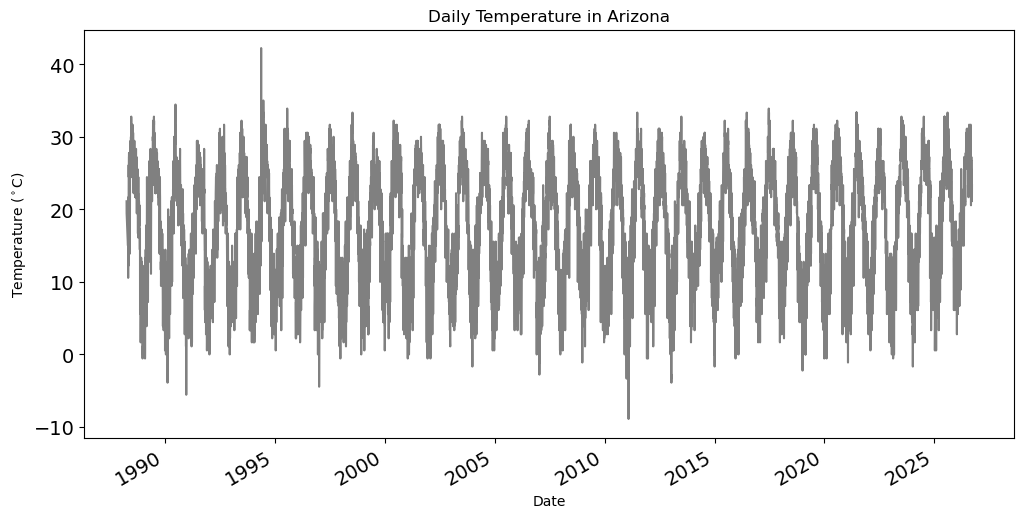

In [24]:
### plot without the legend
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Arizona',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    ### increase fig size
    figsize = (12, 6),
    ### increase font size
    fontsize = 14,
    ### change color
    color = 'grey') 

no_legend.legend().remove()

### Clean up time series plots by resampling

Now we'll resample the data. This summarizes the data as an annual mean value, giving us one data point per year.

In [25]:
### resample to mean annual temps
annual_temp_df = (

    ### resample df
    temp_units_df

    ### sample annually
    .resample('YS')

    ### calculate mean
    .mean()
)

annual_temp_df

,temp_f,temp_c
DATE,,
1988-01-01,69.481781,20.823212
1989-01-01,64.482192,18.045662
1990-01-01,61.824658,16.569254
1991-01-01,61.413699,16.340944
1992-01-01,61.816940,16.564967
1993-01-01,63.158192,17.310107
1994-01-01,63.623626,17.568681
1995-01-01,63.522099,17.512277
1996-01-01,64.123288,17.846271


## Plot the annual data

<Axes: title={'center': 'Mean Annual Temperature in Arizona'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

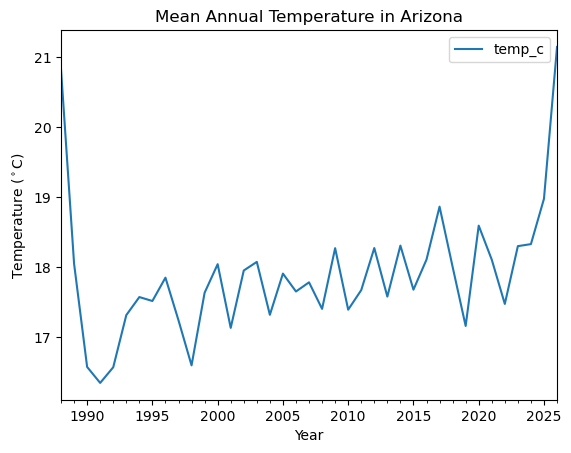

In [26]:
annual_temp_df.plot(y = 'temp_c',
                  title = 'Mean Annual Temperature in Arizona',
                  xlabel = 'Year',
                  ylabel = 'Temperature ($^\circ$C)')

>**Reflect & Respond: Plot Interpretations**
>* In some years, the plotted mean annual temperature is extremely low (<5C) or high (>20C) compared to other years. This could be caused by missing data or the data was not QA/QCed prior to publishing.
>* There is a significant gap in the data sometime between 1935-1940, likely due to missing data (NaNs).
>* Mean annual temperatures are lower in the late 1800s/early 1900s than they are in the 2000s. This could be a result of climate change, but it is difficult to say that conclusively without further analysis/looking at the data more closely.

## Make an interactive plot

In [27]:
### troubleshooting workaround for interactive plot
hvplot.extension("bokeh")

In [28]:
### plot the annual data interactively
annual_temp_plot = annual_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Boulder, CO',
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

annual_temp_plot

:Curve   [DATE]   (temp_c)

>**Reflect & Respond: Data Exploration**
>* The minimum mean annual temperature is 3.731 degrees C in 1994
>* The maximum mean annual temperature is 20.778 degrees C in 1937

## Quantify how fast the climate is changing with a trend line

>**Is linear OLS regression right for this data?**
>
>While our temperature data for Boulder presumably includes random variation caused by things like El Niño and La Niña, it seems a little bit unrealistic to assume that all of the variation in mean annual temperatures is random. We are looking at annual means, not maximum or minimum values, so the data is normally distributed because it doesn't really account for extremes in the same way that daily data would. Our data meets the assumption of a somewhat constant rate of temperature increase because the data was collected in Colorado, not in a place like the Arctic where rates of changes are less linear. The data may not meet the assumption of stationarity, as variability likely changes year to year depending on ocean temperatures, etc., and there may be increased year to year variability in both extreme warm and cold temperatures as a result of climate change. 

In [29]:
### subset data to only include temp in Celsius
annual_temp_c_df = annual_temp_df[['temp_c']]

### subset data to 1988-2025 because 2026 isn't a full year of data
complete_data_df = annual_temp_c_df.loc['1988':'2025']
complete_data_df

,temp_c
DATE,
1988-01-01,20.823212
1989-01-01,18.045662
1990-01-01,16.569254
1991-01-01,16.340944
1992-01-01,16.564967
1993-01-01,17.310107
1994-01-01,17.568681
1995-01-01,17.512277
1996-01-01,17.846271


In [30]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = complete_data_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = complete_data_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.01996211] degrees per year


### Plot your trend line

Trend lines are often used to help your audience understand and process
a time-series plot. In this case, we’ve chosen mean temperature values
rather than extremes, so we think OLS is an appropriate model to use to
show a trend.

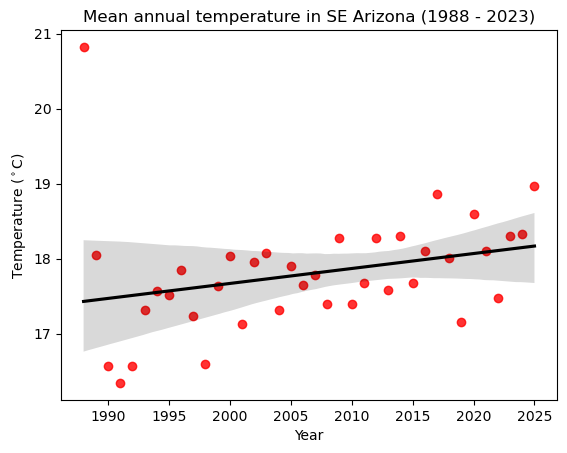

In [31]:
### plot data
ax = sns.regplot(
    x = complete_data_df.index.year, 
    y = complete_data_df.temp_c,

    ### change the color of data points
    color = 'red',

    ### change the color of the trendline
    line_kws= {'color': 'black'}
)

### make labels
ax.set(
    title = 'Mean annual temperature in SE Arizona (1988 - 2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/climate-change/arizona-climate-trendline.jpeg')

### plot it
plt.show()

>*Mean annual temperatures in Boulder, CO have increased over the last century*

>In SE Arizona, mean annual temperatures have increased by 0.012 degrees C per year from 1988 to 2025. Temperatures are likely increasing as a result of climate change, although other environmental characteristics, like trends in sea surface temperatures, may also influence some of this rate of temperature change.